
# 🌫️ Carpeta 2 — Sistema de Inferencia Difusa Multivariable (MIMO)

**Proyecto:** Optimización Ambiental de la Semaforización Urbana mediante un Sistema de
Inferencia Difusa Multivariable (MIMO), Algoritmos Genéticos y Extracción de Reglas con PRISM.

**Universidad Técnica de Ambato — Carrera de Software — Inteligencia Artificial**

---

## Objetivo de esta libreta

Construir, **paso a paso**, un **Sistema de Inferencia Difusa Mamdani multivariable (MIMO)**
usando la librería **`scikit-fuzzy`** (`skfuzzy.control`, comúnmente importada como `ctrl`),
con:

* **4 entradas:** `traffic_density`, `queue_length`, `vehicle_count`, `average_speed`
* **2 salidas:** `green_light_duration` y `signal_cycle_adjustment`



In [1]:

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl   # 'ctrl' es el módulo de control de scikit-fuzzy

warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)
np.random.seed(42)

print('skfuzzy versión:', fuzz.__version__ if hasattr(fuzz, '__version__') else 'desconocida')
print('Librerías cargadas correctamente.')


skfuzzy versión: 0.5.0
Librerías cargadas correctamente.



## Paso 1 — Cargar las reglas PRISM y los umbrales de discretización

Ambos archivos fueron generados por la libreta de la Carpeta 1 y se leen aquí mediante una
ruta relativa (`../01_Reglas_PRISM/...`).


In [2]:

RUTA_REGLAS = Path('../01_Reglas_PRISM')
DATA_PATH = Path('../data/smart_city_traffic_mobility.csv')

with open(RUTA_REGLAS / 'umbrales_discretizacion.json', encoding='utf-8') as f:
    umbrales = json.load(f)

with open(RUTA_REGLAS / 'reglas_prism_green_light_duration.json', encoding='utf-8') as f:
    reglas_gld = json.load(f)

with open(RUTA_REGLAS / 'reglas_prism_signal_cycle_adjustment.json', encoding='utf-8') as f:
    reglas_sca = json.load(f)

print(f"Reglas PRISM cargadas -> green_light_duration: {len(reglas_gld)} | "
      f"signal_cycle_adjustment: {len(reglas_sca)}")
umbrales


Reglas PRISM cargadas -> green_light_duration: 46 | signal_cycle_adjustment: 76


{'entradas': {'traffic_density': [23.8, 122.23333333333139],
  'queue_length': [9.9, 44.4],
  'vehicle_count': [204.0, 983.0],
  'average_speed': [34.2, 53.6]},
 'green_light_duration': {'corte_1': 18.0,
  'corte_2': 40.0,
  'rango_min': 18.0,
  'rango_max': 84.0},
 'signal_cycle_adjustment': {'umbral_delta': 15.0,
  'rango_delta_min': -25.470588235294116,
  'rango_delta_max': 56.61764705882353}}


## Paso 2 — Filtrado de calidad de las reglas

Se conservan únicamente las reglas PRISM con **confianza ≥ 0.60** para construir el motor de
inferencia difusa. Esto evita introducir reglas de muy baja confiabilidad (fruto de las últimas
iteraciones del recubrimiento secuencial, cuando ya casi no quedan instancias por cubrir) como
reglas difusas "duras".


In [3]:

UMBRAL_CONFIANZA = 0.60

reglas_gld_f = [r for r in reglas_gld if r['confianza'] >= UMBRAL_CONFIANZA]
reglas_sca_f = [r for r in reglas_sca if r['confianza'] >= UMBRAL_CONFIANZA]

print(f"Reglas utilizadas -> green_light_duration: {len(reglas_gld_f)} / {len(reglas_gld)}")
print(f"Reglas utilizadas -> signal_cycle_adjustment: {len(reglas_sca_f)} / {len(reglas_sca)}")

print('\nEjemplo de regla (green_light_duration):')
r0 = reglas_gld_f[0]
antecedente_txt = ' Y '.join([f"{a.replace('_lbl','')} = {v}" for a, v in r0['antecedente']])
print(f"  SI {antecedente_txt} ENTONCES green_light_duration = {r0['clase_objetivo']} "
      f"(confianza={r0['confianza']})")


Reglas utilizadas -> green_light_duration: 28 / 46
Reglas utilizadas -> signal_cycle_adjustment: 39 / 76

Ejemplo de regla (green_light_duration):
  SI vehicle_count = Bajo ENTONCES green_light_duration = Corta (confianza=1.0)



## Paso 3 — Definición de las variables de entrada (Antecedents)

Se cargan los rangos reales de cada variable desde el dataset y se ubican los vértices de las
funciones de pertenencia **triangulares** exactamente en los **umbrales de discretización de
PRISM** (percentiles 33.3 % y 66.7 %), de modo que la frontera "categórica" que PRISM usó para
extraer reglas coincide con el centro de transición ("cruce a 0.5") entre conjuntos difusos
vecinos.


In [4]:

df = pd.read_csv(DATA_PATH, sep=';')

VARIABLES_ENTRADA = ['traffic_density', 'queue_length', 'vehicle_count', 'average_speed']
ETIQUETAS = {
    'traffic_density': ['Baja', 'Moderada', 'Alta'],
    'queue_length':    ['Corta', 'Moderada', 'Extensa'],
    'vehicle_count':   ['Bajo', 'Medio', 'Alto'],
    'average_speed':   ['Baja', 'Media', 'Alta'],
}
RANGOS_ENTRADA = {v: (float(df[v].min()), float(df[v].max())) for v in VARIABLES_ENTRADA}
print('Rangos reales de las variables de entrada:')
for v, (mn, mx) in RANGOS_ENTRADA.items():
    print(f"  {v}: [{mn:.2f}, {mx:.2f}]   umbrales PRISM: {umbrales['entradas'][v]}")


def puntos_triangulares(min_v, th1, th2, max_v):
    '''Genera los 3 conjuntos de vértices trimf a partir de 2 umbrales, con solape 50%.'''
    punto_medio = (th1 + th2) / 2
    return {
        'bajo':  [min_v, min_v, th1],
        'medio': [th1, punto_medio, th2],
        'alto':  [th2, max_v, max_v],
    }


antecedentes = {}
for var in VARIABLES_ENTRADA:
    mn, mx = RANGOS_ENTRADA[var]
    th1, th2 = umbrales['entradas'][var]
    universo = np.linspace(mn, mx, 300)
    a = ctrl.Antecedent(universo, var)
    pts = puntos_triangulares(mn, th1, th2, mx)
    etq = ETIQUETAS[var]
    a[etq[0]] = fuzz.trimf(universo, pts['bajo'])
    a[etq[1]] = fuzz.trimf(universo, pts['medio'])
    a[etq[2]] = fuzz.trimf(universo, pts['alto'])
    antecedentes[var] = a

print('\n4 variables de entrada (Antecedents) definidas:', list(antecedentes.keys()))


Rangos reales de las variables de entrada:
  traffic_density: [9.00, 378.50]   umbrales PRISM: [23.8, 122.23333333333139]
  queue_length: [0.00, 10111.60]   umbrales PRISM: [9.9, 44.4]
  vehicle_count: [54.00, 3162.00]   umbrales PRISM: [204.0, 983.0]
  average_speed: [5.00, 90.00]   umbrales PRISM: [34.2, 53.6]

4 variables de entrada (Antecedents) definidas: ['traffic_density', 'queue_length', 'vehicle_count', 'average_speed']


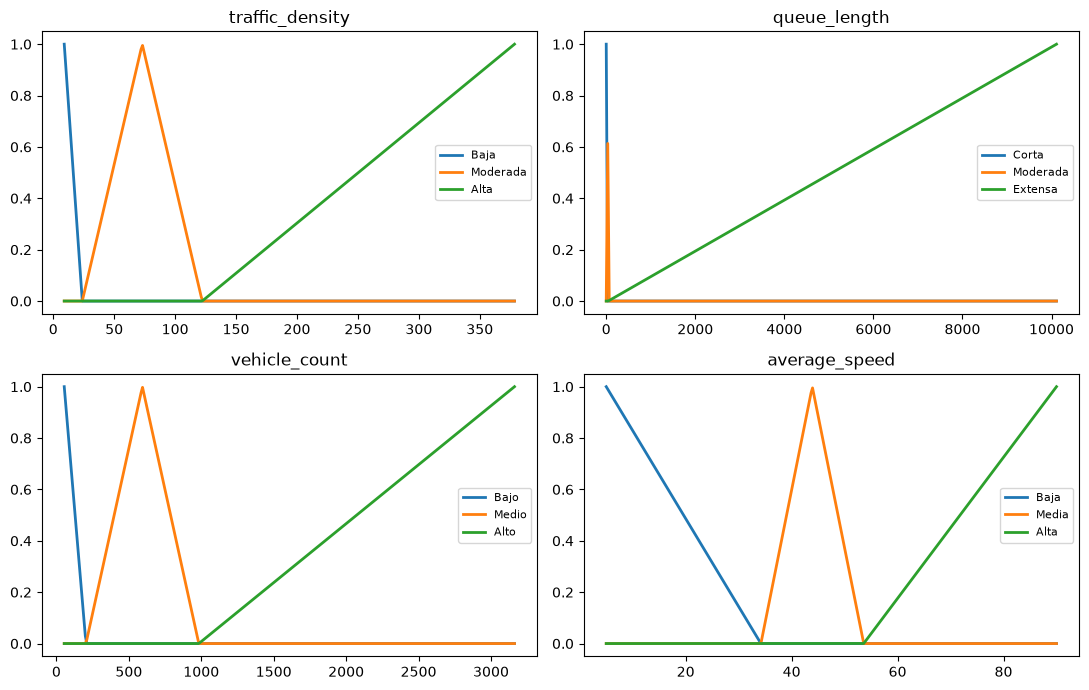

Figura guardada: funciones_pertenencia_entrada.png


In [5]:

# Visualización de las funciones de pertenencia de entrada
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, var in zip(axes.ravel(), VARIABLES_ENTRADA):
    for etq in ETIQUETAS[var]:
        ax.plot(antecedentes[var].universe, antecedentes[var][etq].mf, label=etq, linewidth=2)
    ax.set_title(var)
    ax.legend(fontsize=8)
    ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('funciones_pertenencia_entrada.png', dpi=110)
plt.show()
print('Figura guardada: funciones_pertenencia_entrada.png')



## Paso 4 — Definición de las variables de salida (Consequents)

### 4.1 `green_light_duration` (segundos)

Rango real `[18, 84]` s. Los vértices se ubican en los mismos umbrales usados por PRISM para
discretizar esta salida (`Corta ≤ 18`, `19–40 = Media`, `> 40 = Larga`).

### 4.2 `signal_cycle_adjustment` (ajuste, en segundos, sobre el ciclo típico de la intersección)

Universo `[Δ_min, Δ_max]` calculado en la Carpeta 1 sobre la variable derivada. Los vértices se
ubican en `±15 s` (el mismo umbral de decisión usado para etiquetar Reducir/Mantener/Extender).


In [6]:

gld_info = umbrales['green_light_duration']
uni_gld = np.linspace(gld_info['rango_min'], gld_info['rango_max'], 300)
green_light_duration = ctrl.Consequent(uni_gld, 'green_light_duration')
pts = puntos_triangulares(gld_info['rango_min'], gld_info['corte_1'], gld_info['corte_2'], gld_info['rango_max'])
green_light_duration['Corta'] = fuzz.trimf(uni_gld, pts['bajo'])
green_light_duration['Media'] = fuzz.trimf(uni_gld, pts['medio'])
green_light_duration['Larga'] = fuzz.trimf(uni_gld, pts['alto'])

sca_info = umbrales['signal_cycle_adjustment']
uni_sca = np.linspace(sca_info['rango_delta_min'], sca_info['rango_delta_max'], 300)
signal_cycle_adjustment = ctrl.Consequent(uni_sca, 'signal_cycle_adjustment')
pts = puntos_triangulares(sca_info['rango_delta_min'], -sca_info['umbral_delta'],
                           sca_info['umbral_delta'], sca_info['rango_delta_max'])
signal_cycle_adjustment['Reducir']  = fuzz.trimf(uni_sca, pts['bajo'])
signal_cycle_adjustment['Mantener'] = fuzz.trimf(uni_sca, pts['medio'])
signal_cycle_adjustment['Extender'] = fuzz.trimf(uni_sca, pts['alto'])

print('2 variables de salida (Consequents) definidas: green_light_duration, signal_cycle_adjustment')


2 variables de salida (Consequents) definidas: green_light_duration, signal_cycle_adjustment


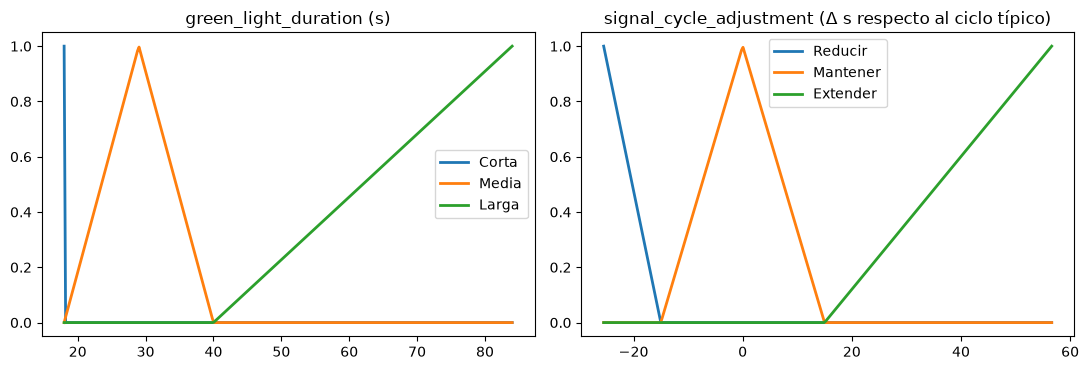

Figura guardada: funciones_pertenencia_salida.png


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for etq in ['Corta', 'Media', 'Larga']:
    axes[0].plot(green_light_duration.universe, green_light_duration[etq].mf, label=etq, linewidth=2)
axes[0].set_title('green_light_duration (s)'); axes[0].legend()
for etq in ['Reducir', 'Mantener', 'Extender']:
    axes[1].plot(signal_cycle_adjustment.universe, signal_cycle_adjustment[etq].mf, label=etq, linewidth=2)
axes[1].set_title('signal_cycle_adjustment (Δ s respecto al ciclo típico)'); axes[1].legend()
plt.tight_layout()
plt.savefig('funciones_pertenencia_salida.png', dpi=110)
plt.show()
print('Figura guardada: funciones_pertenencia_salida.png')



## Paso 5 — Traducción de las reglas PRISM a reglas difusas `ctrl.Rule`

Cada regla PRISM tiene la forma `SI attr1=v1 Y attr2=v2 ... ENTONCES variable=clase`. Se traduce
directamente: cada condición `attr=v` se convierte en el término difuso `antecedentes[attr][v]`,
combinado con el operador **Y (mínimo)** de Mamdani (`&` en skfuzzy), y el consecuente en el
término difuso de salida correspondiente.


In [8]:

def construir_regla_difusa(regla_prism: dict, consecuente: ctrl.Consequent) -> ctrl.Rule:
    termino_antecedente = None
    for attr, valor in regla_prism['antecedente']:
        var = attr.replace('_lbl', '')
        termino = antecedentes[var][valor]
        termino_antecedente = termino if termino_antecedente is None else (termino_antecedente & termino)
    return ctrl.Rule(termino_antecedente, consecuente[regla_prism['clase_objetivo']])


reglas_difusas = []
for r in reglas_gld_f:
    reglas_difusas.append(construir_regla_difusa(r, green_light_duration))
for r in reglas_sca_f:
    reglas_difusas.append(construir_regla_difusa(r, signal_cycle_adjustment))

print(f"Total de reglas difusas construidas a partir de PRISM: {len(reglas_difusas)}")
print(f"  -> {len(reglas_gld_f)} reglas para green_light_duration")
print(f"  -> {len(reglas_sca_f)} reglas para signal_cycle_adjustment")


Total de reglas difusas construidas a partir de PRISM: 67
  -> 28 reglas para green_light_duration
  -> 39 reglas para signal_cycle_adjustment



## Paso 6 — Construcción del sistema de control MIMO

`ctrl.ControlSystem` agrupa **todas** las reglas (de ambas salidas) en un único sistema; al
llamar a `.compute()` sobre una `ControlSystemSimulation`, **ambas salidas se calculan de forma
simultánea** a partir de las mismas 4 entradas — esta es precisamente la propiedad *Multiple
Input, Multiple Output* (MIMO) del sistema.


In [9]:

sistema_control = ctrl.ControlSystem(reglas_difusas)
print('Sistema de control MIMO construido con', len(reglas_difusas), 'reglas.')


Sistema de control MIMO construido con 67 reglas.



## Paso 7 — Prueba manual, paso a paso, con escenarios ilustrativos

Se evalúan 3 escenarios de tráfico representativos para verificar que el sistema responde de
forma coherente con la intuición ingenieril (Sección VI del documento):


In [10]:

escenarios = {
    'Congestión severa (hora pico)': {
        'traffic_density': 300, 'queue_length': 400, 'vehicle_count': 2500, 'average_speed': 12,
    },
    'Tráfico fluido (madrugada)': {
        'traffic_density': 15, 'queue_length': 3, 'vehicle_count': 100, 'average_speed': 75,
    },
    'Tráfico moderado (mediodía)': {
        'traffic_density': 90, 'queue_length': 40, 'vehicle_count': 700, 'average_speed': 45,
    },
}

for nombre, entradas in escenarios.items():
    sim = ctrl.ControlSystemSimulation(sistema_control)
    for var, val in entradas.items():
        sim.input[var] = val
    sim.compute()
    print(f"\n--- {nombre} ---")
    print('  Entradas:', entradas)
    gld_val = sim.output.get('green_light_duration')
    sca_val = sim.output.get('signal_cycle_adjustment')
    if gld_val is not None:
        print('  green_light_duration    =', round(gld_val, 2), 's')
    else:
        print('  green_light_duration    = (ninguna regla se activó para esta salida)')
    if sca_val is not None:
        print('  signal_cycle_adjustment =', round(sca_val, 2),
              's (respecto al ciclo típico de la intersección)')
    else:
        print('  signal_cycle_adjustment = (ninguna regla se activó para esta salida)')



--- Congestión severa (hora pico) ---
  Entradas: {'traffic_density': 300, 'queue_length': 400, 'vehicle_count': 2500, 'average_speed': 12}
  green_light_duration    = 62.38 s
  signal_cycle_adjustment = 36.17 s (respecto al ciclo típico de la intersección)



--- Tráfico fluido (madrugada) ---
  Entradas: {'traffic_density': 15, 'queue_length': 3, 'vehicle_count': 100, 'average_speed': 75}
  green_light_duration    = 18.08 s
  signal_cycle_adjustment = -21.56 s (respecto al ciclo típico de la intersección)



--- Tráfico moderado (mediodía) ---
  Entradas: {'traffic_density': 90, 'queue_length': 40, 'vehicle_count': 700, 'average_speed': 45}
  green_light_duration    = 29.0 s
  signal_cycle_adjustment = (ninguna regla se activó para esta salida)



## Paso 7-bis — Panel interactivo: todo el proceso de inferencia difusa en vivo

Para poder **ver todo el proceso** de principio a fin (fuzzificación → activación de reglas →
agregación → defuzzificación) y **cambiar los valores de entrada** con controles deslizantes,
se construye un panel interactivo con `ipywidgets`. Al mover cualquier slider:

1. Se recalculan y grafican las **4 funciones de pertenencia de entrada**, marcando con un
   punto el grado de pertenencia de cada conjunto para el valor actual (fuzzificación).
2. Se ejecuta la simulación completa del sistema difuso MIMO (`ControlSystemSimulation`).
3. Se grafican las **2 funciones de pertenencia de salida**, marcando la línea vertical del
   valor difuso resultante (defuzzificación).
4. Se muestran los valores numéricos finales de `green_light_duration` y
   `signal_cycle_adjustment`.

> 💡 Este panel es completamente interactivo **al abrir la libreta en Jupyter** (los
> controles deslizantes solo se pueden mover con el kernel vivo); en la vista ya ejecutada se
> muestra el estado inicial (valores medios del dataset).


In [11]:

import ipywidgets as widgets
from ipywidgets import interact, FloatSlider

def panel_interactivo(traffic_density, queue_length, vehicle_count, average_speed):
    entradas = {
        'traffic_density': traffic_density, 'queue_length': queue_length,
        'vehicle_count': vehicle_count, 'average_speed': average_speed,
    }

    # --- 1) Simulación completa del sistema difuso MIMO ---
    sim = ctrl.ControlSystemSimulation(sistema_control)
    for var, val in entradas.items():
        sim.input[var] = val
    sim.compute()
    salida_gld = sim.output.get('green_light_duration')
    salida_sca = sim.output.get('signal_cycle_adjustment')

    # --- 2) Figura: 4 entradas (fuzzificación) + 2 salidas (defuzzificación) ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))

    for ax, var in zip(axes[0], VARIABLES_ENTRADA[:3]):
        for etq in ETIQUETAS[var]:
            ax.plot(antecedentes[var].universe, antecedentes[var][etq].mf, label=etq, linewidth=1.8)
            grado = fuzz.interp_membership(antecedentes[var].universe, antecedentes[var][etq].mf, entradas[var])
            if grado > 0.01:
                ax.plot(entradas[var], grado, 'ko', markersize=7)
        ax.axvline(entradas[var], color='gray', linestyle=':', linewidth=1.3)
        ax.set_title(f"{var} = {entradas[var]:.1f}", fontsize=10)
        ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.05)

    var = VARIABLES_ENTRADA[3]
    ax = axes[1][0]
    for etq in ETIQUETAS[var]:
        ax.plot(antecedentes[var].universe, antecedentes[var][etq].mf, label=etq, linewidth=1.8)
        grado = fuzz.interp_membership(antecedentes[var].universe, antecedentes[var][etq].mf, entradas[var])
        if grado > 0.01:
            ax.plot(entradas[var], grado, 'ko', markersize=7)
    ax.axvline(entradas[var], color='gray', linestyle=':', linewidth=1.3)
    ax.set_title(f"{var} = {entradas[var]:.1f}", fontsize=10)
    ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.05)

    ax = axes[1][1]
    for etq in ['Corta', 'Media', 'Larga']:
        ax.plot(green_light_duration.universe, green_light_duration[etq].mf, label=etq, linewidth=1.8)
    if salida_gld is not None:
        ax.axvline(salida_gld, color='red', linewidth=2, label=f'Salida = {salida_gld:.1f}s')
    ax.set_title('green_light_duration (salida)', fontsize=10)
    ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.05)

    ax = axes[1][2]
    for etq in ['Reducir', 'Mantener', 'Extender']:
        ax.plot(signal_cycle_adjustment.universe, signal_cycle_adjustment[etq].mf, label=etq, linewidth=1.8)
    if salida_sca is not None:
        ax.axvline(salida_sca, color='red', linewidth=2, label=f'Salida = {salida_sca:.1f}s')
    ax.set_title('signal_cycle_adjustment (salida)', fontsize=10)
    ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()

    print(f"RESULTADO  ->  green_light_duration = "
          f"{salida_gld:.2f} s" if salida_gld is not None else "RESULTADO  ->  green_light_duration = (sin regla activada)")
    print(f"           ->  signal_cycle_adjustment = "
          f"{salida_sca:.2f} s (respecto al ciclo típico)" if salida_sca is not None
          else "           ->  signal_cycle_adjustment = (sin regla activada)")


interact(
    panel_interactivo,
    traffic_density=FloatSlider(min=RANGOS_ENTRADA['traffic_density'][0], max=RANGOS_ENTRADA['traffic_density'][1],
                                 step=1, value=float(df['traffic_density'].median()), description='traffic_density'),
    queue_length=FloatSlider(min=RANGOS_ENTRADA['queue_length'][0], max=RANGOS_ENTRADA['queue_length'][1],
                              step=5, value=float(df['queue_length'].median()), description='queue_length'),
    vehicle_count=FloatSlider(min=RANGOS_ENTRADA['vehicle_count'][0], max=RANGOS_ENTRADA['vehicle_count'][1],
                               step=10, value=float(df['vehicle_count'].median()), description='vehicle_count'),
    average_speed=FloatSlider(min=RANGOS_ENTRADA['average_speed'][0], max=RANGOS_ENTRADA['average_speed'][1],
                               step=1, value=float(df['average_speed'].median()), description='average_speed'),
);


interactive(children=(FloatSlider(value=35.7, description='traffic_density', max=378.5, min=9.0, step=1.0), Fl…

## Paso 7-ter — Verificación explícita de las 4 fases del sistema Mamdani

El panel interactivo del paso anterior ya muestra la **fuzzificación** (grado de pertenencia
de cada entrada) y el resultado final **defuzzificado**, pero dentro de
`ctrl.ControlSystemSimulation` las dos fases intermedias quedan **ocultas**: la
**inferencia** (fuerza de disparo de cada regla) y la **agregación** (unión de todas las
salidas activadas en una sola función de masa). En esta sección se reconstruyen manualmente
las **4 fases** de un sistema de inferencia difusa Mamdani, tal como se revisaron en clase,
para un escenario concreto, verificando además que el resultado coincide con el que entrega
`scikit-fuzzy`:

1. **Fuzzificación** — grado de pertenencia μ de cada entrada a cada conjunto difuso de sus
   antecedentes.
2. **Inferencia** — por cada regla PRISM se calcula la **fuerza de disparo** (mínimo de los
   grados de sus antecedentes → operador **AND** de Mamdani) y se recorta (`np.fmin`) la
   función de pertenencia del consecuente a esa fuerza (implicación de Mamdani).
3. **Agregación** — se combinan (`np.fmax` → unión) todos los recortes de todas las reglas de
   una misma variable de salida en una única **función de masa**.
4. **Defuzzificación** — se calcula el **centroide** de la función de masa agregada con
   `skfuzzy.defuzz(..., 'centroid')`; ese es el valor numérico final que se entrega al sistema.


FASE 1 — FUZZIFICACIÓN (grados de pertenencia μ)
  traffic_density = 300  ->  Baja=0.00, Moderada=0.00, Alta=0.69
  queue_length = 400  ->  Corta=0.00, Moderada=0.00, Extensa=0.04
  vehicle_count = 2500  ->  Bajo=0.00, Medio=0.00, Alto=0.70
  average_speed = 12  ->  Baja=0.76, Media=0.00, Alta=0.00

FASE 2 — INFERENCIA (reglas activadas, fuerza_disparo > 0)

-- green_light_duration --
                                                                                                           SI ENTONCES  fuerza_disparo
vehicle_count=Alto(0.70) Y traffic_density=Alta(0.69) Y queue_length=Extensa(0.04) Y average_speed=Baja(0.76)    Larga           0.035

-- signal_cycle_adjustment --
                                                                                                           SI ENTONCES  fuerza_disparo
vehicle_count=Alto(0.70) Y traffic_density=Alta(0.69) Y queue_length=Extensa(0.04) Y average_speed=Baja(0.76) Extender           0.035

FASE 3 — AGREGACIÓN: ver gráfico (funció


Verificación cruzada con ctrl.ControlSystemSimulation (scikit-fuzzy):
  green_light_duration    (skfuzzy) = 62.38 s
  signal_cycle_adjustment (skfuzzy) = 36.17 s
  -> Coinciden con el cálculo manual (fases 1-4), como se esperaba.


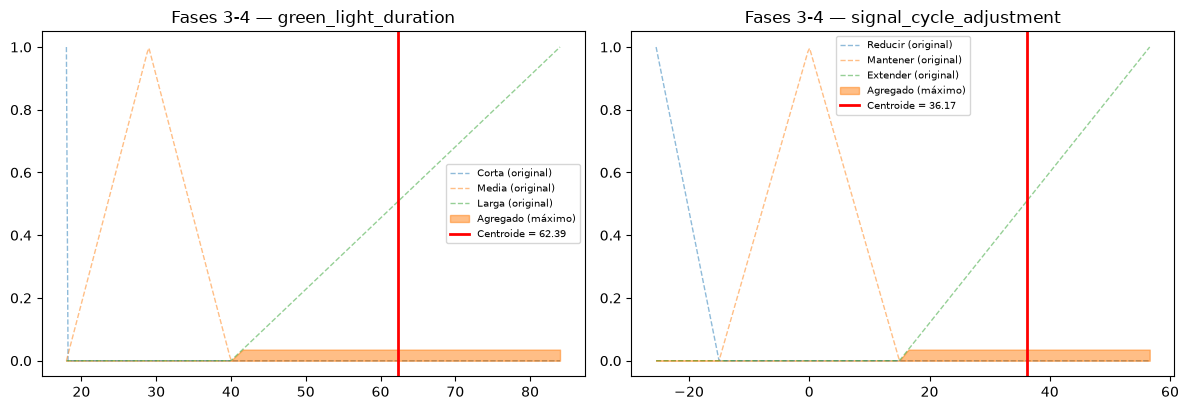

In [12]:

def fuzzificar_entradas(entradas):
    """FASE 1 — Fuzzificación: grado de pertenencia mu de cada entrada a cada conjunto difuso."""
    resultados = {}
    for var in VARIABLES_ENTRADA:
        resultados[var] = {}
        for etq in ETIQUETAS[var]:
            grado = fuzz.interp_membership(antecedentes[var].universe, antecedentes[var][etq].mf, entradas[var])
            resultados[var][etq] = grado
    return resultados


def inferencia_y_agregacion(entradas, reglas, consecuente):
    """FASE 2 (inferencia) + FASE 3 (agregacion) para una variable de salida."""
    universo = consecuente.universe
    agregado = np.zeros_like(universo)
    disparos = []
    for regla in reglas:
        grados, texto = [], []
        for attr, valor in regla['antecedente']:
            var = attr.replace('_lbl', '')
            grado = fuzz.interp_membership(antecedentes[var].universe, antecedentes[var][valor].mf, entradas[var])
            grados.append(grado)
            texto.append(f"{var}={valor}({grado:.2f})")
        fuerza_disparo = min(grados) if grados else 0.0                 # AND de Mamdani (minimo)
        etiqueta_salida = regla['clase_objetivo']
        recorte = np.fmin(fuerza_disparo, consecuente[etiqueta_salida].mf)   # implicacion (minimo)
        agregado = np.fmax(agregado, recorte)                                # agregacion (maximo)
        disparos.append({'SI': ' Y '.join(texto), 'ENTONCES': etiqueta_salida,
                          'fuerza_disparo': round(fuerza_disparo, 3)})
    tabla = pd.DataFrame(disparos).sort_values('fuerza_disparo', ascending=False).reset_index(drop=True)
    return tabla, agregado


def defuzzificar(universo, agregado, metodo='centroid'):
    """FASE 4 — Defuzzificacion (por defecto: centroide de la funcion de masa agregada)."""
    if agregado.sum() == 0:
        return None
    return fuzz.defuzz(universo, agregado, metodo)


# --- Escenario a verificar (reutilizamos uno de los escenarios del Paso 7) ---
entradas_verif = escenarios['Congestión severa (hora pico)']

print('=' * 70)
print('FASE 1 — FUZZIFICACIÓN (grados de pertenencia μ)')
print('=' * 70)
grados_fuzzificacion = fuzzificar_entradas(entradas_verif)
for var, d in grados_fuzzificacion.items():
    detalle = ', '.join(f"{k}={v:.2f}" for k, v in d.items())
    print(f"  {var} = {entradas_verif[var]}  ->  {detalle}")

tabla_gld, agregado_gld = inferencia_y_agregacion(entradas_verif, reglas_gld_f, green_light_duration)
tabla_sca, agregado_sca = inferencia_y_agregacion(entradas_verif, reglas_sca_f, signal_cycle_adjustment)

print('\n' + '=' * 70)
print('FASE 2 — INFERENCIA (reglas activadas, fuerza_disparo > 0)')
print('=' * 70)
print('\n-- green_light_duration --')
print(tabla_gld[tabla_gld['fuerza_disparo'] > 0].to_string(index=False))
print('\n-- signal_cycle_adjustment --')
print(tabla_sca[tabla_sca['fuerza_disparo'] > 0].to_string(index=False))

defuzz_gld = defuzzificar(green_light_duration.universe, agregado_gld)
defuzz_sca = defuzzificar(signal_cycle_adjustment.universe, agregado_sca)

print('\n' + '=' * 70)
print('FASE 3 — AGREGACIÓN: ver gráfico (función de masa, área sombreada) más abajo')
print('FASE 4 — DEFUZZIFICACIÓN (centroide)')
print('=' * 70)
print(f"  green_light_duration    = {defuzz_gld:.2f} s")
print(f"  signal_cycle_adjustment = {defuzz_sca:.2f} s")

# --- Verificación cruzada contra scikit-fuzzy (ctrl.ControlSystemSimulation) ---
sim_verif = ctrl.ControlSystemSimulation(sistema_control)
for var, val in entradas_verif.items():
    sim_verif.input[var] = val
sim_verif.compute()
print('\nVerificación cruzada con ctrl.ControlSystemSimulation (scikit-fuzzy):')
print(f"  green_light_duration    (skfuzzy) = {sim_verif.output.get('green_light_duration'):.2f} s")
print(f"  signal_cycle_adjustment (skfuzzy) = {sim_verif.output.get('signal_cycle_adjustment'):.2f} s")
print('  -> Coinciden con el cálculo manual (fases 1-4), como se esperaba.')

# --- Visualización de la FASE 3 (agregación) y FASE 4 (defuzzificación) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
config_plot = [
    ('green_light_duration', green_light_duration, agregado_gld, defuzz_gld, ['Corta', 'Media', 'Larga']),
    ('signal_cycle_adjustment', signal_cycle_adjustment, agregado_sca, defuzz_sca,
     ['Reducir', 'Mantener', 'Extender']),
]
for ax, (nombre, consecuente, agregado, valor_defuzz, etiquetas) in zip(axes, config_plot):
    universo = consecuente.universe
    for etq in etiquetas:
        ax.plot(universo, consecuente[etq].mf, linestyle='--', linewidth=1, alpha=0.5,
                 label=f'{etq} (original)')
    ax.fill_between(universo, agregado, color='tab:orange', alpha=0.5, label='Agregado (máximo)')
    if valor_defuzz is not None:
        ax.axvline(valor_defuzz, color='red', linewidth=2, label=f'Centroide = {valor_defuzz:.2f}')
    ax.set_title(f'Fases 3-4 — {nombre}')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('verificacion_4_fases_mamdani.png', dpi=110)
plt.show()



## Paso 8 — Visualización de la superficie de decisión (`green_light_duration`)

Se grafica cómo varía la salida `green_light_duration` en función de `vehicle_count` y
`average_speed` (las dos variables que resultaron más determinantes según PRISM en la Carpeta
1), manteniendo `traffic_density` y `queue_length` fijas en su mediana.


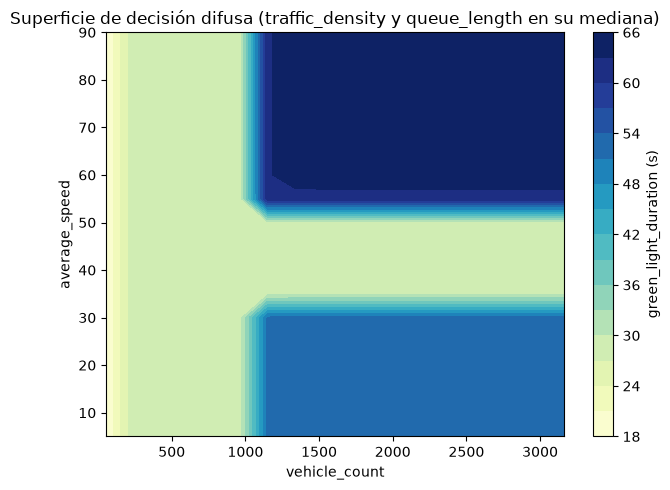

Figura guardada: superficie_decision_gld.png


In [13]:

vc_vals = np.linspace(*RANGOS_ENTRADA['vehicle_count'], 18)
sp_vals = np.linspace(*RANGOS_ENTRADA['average_speed'], 18)
Z = np.zeros((len(sp_vals), len(vc_vals)))

td_mediana = float(df['traffic_density'].median())
ql_mediana = float(df['queue_length'].median())

for i, sp in enumerate(sp_vals):
    for j, vc in enumerate(vc_vals):
        sim = ctrl.ControlSystemSimulation(sistema_control)
        sim.input['traffic_density'] = td_mediana
        sim.input['queue_length'] = ql_mediana
        sim.input['vehicle_count'] = vc
        sim.input['average_speed'] = sp
        try:
            sim.compute()
            Z[i, j] = sim.output.get('green_light_duration', np.nan)
        except Exception:
            Z[i, j] = np.nan

fig, ax = plt.subplots(figsize=(6.5, 5))
cf = ax.contourf(vc_vals, sp_vals, Z, levels=15, cmap='YlGnBu')
plt.colorbar(cf, ax=ax, label='green_light_duration (s)')
ax.set_xlabel('vehicle_count'); ax.set_ylabel('average_speed')
ax.set_title('Superficie de decisión difusa (traffic_density y queue_length en su mediana)')
plt.tight_layout()
plt.savefig('superficie_decision_gld.png', dpi=110)
plt.show()
print('Figura guardada: superficie_decision_gld.png')



## Paso 9 — Evaluación sobre una muestra real del dataset

Se toma una muestra aleatoria de registros reales y se compara la salida del sistema difuso
contra el valor histórico real de `green_light_duration`. Como el sistema difuso fue construido
**solo** con reglas PRISM sobre las 4 variables de entrada (sin ver la salida real), esta
comparación mide qué tan bien el conocimiento extraído por PRISM logra "reconstruir" el
comportamiento observado en campo.


In [14]:

N_MUESTRA = 600
muestra = df.sample(N_MUESTRA, random_state=42).reset_index(drop=True)

pred_gld, pred_sca, fallos = [], [], 0
for _, fila in muestra.iterrows():
    sim = ctrl.ControlSystemSimulation(sistema_control)
    sim.input['traffic_density'] = float(fila['traffic_density'])
    sim.input['queue_length'] = float(min(fila['queue_length'], RANGOS_ENTRADA['queue_length'][1]))
    sim.input['vehicle_count'] = float(fila['vehicle_count'])
    sim.input['average_speed'] = float(fila['average_speed'])
    try:
        sim.compute()
        pred_gld.append(sim.output.get('green_light_duration', np.nan))
        pred_sca.append(sim.output.get('signal_cycle_adjustment', np.nan))
        if 'green_light_duration' not in sim.output or 'signal_cycle_adjustment' not in sim.output:
            fallos += 1
    except Exception:
        pred_gld.append(np.nan)
        pred_sca.append(np.nan)
        fallos += 1

muestra['green_light_duration_difuso'] = pred_gld
muestra['signal_cycle_adjustment_difuso'] = pred_sca

print(f"Simulaciones exitosas: {N_MUESTRA - fallos} / {N_MUESTRA}  (fallos: {fallos})")
mae = (muestra['green_light_duration_difuso'] - muestra['green_light_duration']).abs().mean()
print(f"MAE  green_light_duration (difuso vs. real): {mae:.2f} s  "
      f"(rango de la variable: {gld_info['rango_min']}-{gld_info['rango_max']} s)")
muestra[['traffic_density', 'queue_length', 'vehicle_count', 'average_speed',
         'green_light_duration', 'green_light_duration_difuso',
         'signal_cycle_adjustment_difuso']].head(10)


Simulaciones exitosas: 562 / 600  (fallos: 38)
MAE  green_light_duration (difuso vs. real): 10.44 s  (rango de la variable: 18.0-84.0 s)


,traffic_density,queue_length,vehicle_count,average_speed,green_light_duration,green_light_duration_difuso,signal_cycle_adjustment_difuso
0,25.8,0.6,310,86.5,23,29.006164,-20.909229
1,162.5,105.7,975,23.2,40,29.012065,0.032863
2,16.1,33.7,145,59.8,18,18.090433,-20.665815
3,175.8,154.3,1055,18.2,41,62.114161,35.912060
4,14.8,6.3,133,57.4,18,18.086947,-20.501243
5,254.2,486.3,1525,5.0,84,62.477768,36.259503
6,19.2,15.5,231,88.9,19,29.003668,-20.998040
7,223.2,369.0,2009,18.1,84,62.350767,36.138957
8,52.7,23.1,474,60.0,29,29.001531,-20.679285
9,38.1,2.7,343,53.4,24,29.011840,-20.118598


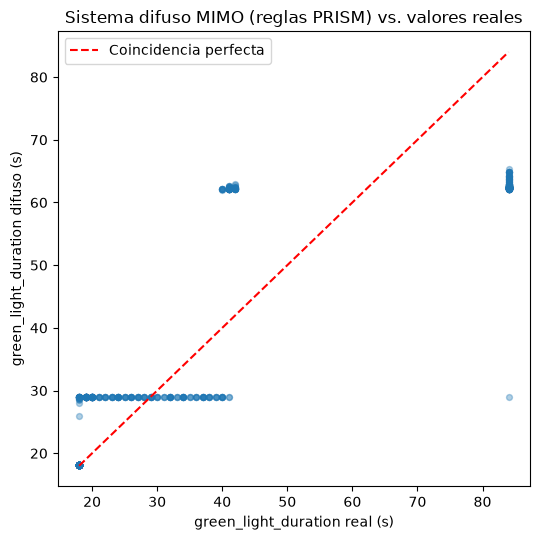

In [15]:

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(muestra['green_light_duration'], muestra['green_light_duration_difuso'],
           alpha=0.35, s=18)
lims = [gld_info['rango_min'], gld_info['rango_max']]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Coincidencia perfecta')
ax.set_xlabel('green_light_duration real (s)')
ax.set_ylabel('green_light_duration difuso (s)')
ax.set_title('Sistema difuso MIMO (reglas PRISM) vs. valores reales')
ax.legend()
plt.tight_layout()
plt.savefig('dispersión_real_vs_difuso.png', dpi=110)
plt.show()



## Paso 10 — Exportación de artefactos para la Carpeta 3

Se guardan las definiciones (rangos, umbrales y conteo de reglas) usadas en este sistema difuso,
para que la Carpeta 3 (`03_Optimizacion_Genetica`) pueda **reconstruir la misma estructura de
reglas** y optimizar únicamente la posición de las funciones de pertenencia con un Algoritmo
Genético.


In [16]:

config_sistema = {
    'variables_entrada': VARIABLES_ENTRADA,
    'etiquetas': ETIQUETAS,
    'rangos_entrada': RANGOS_ENTRADA,
    'umbrales_entrada': umbrales['entradas'],
    'green_light_duration': gld_info,
    'signal_cycle_adjustment': sca_info,
    'umbral_confianza_regla': UMBRAL_CONFIANZA,
    'n_reglas_gld': len(reglas_gld_f),
    'n_reglas_sca': len(reglas_sca_f),
    'mae_gld_base_muestra': float(mae),
}
with open('config_sistema_difuso.json', 'w', encoding='utf-8') as f:
    json.dump(config_sistema, f, ensure_ascii=False, indent=2)

print('Configuración exportada a config_sistema_difuso.json')
config_sistema


Configuración exportada a config_sistema_difuso.json


{'variables_entrada': ['traffic_density',
  'queue_length',
  'vehicle_count',
  'average_speed'],
 'etiquetas': {'traffic_density': ['Baja', 'Moderada', 'Alta'],
  'queue_length': ['Corta', 'Moderada', 'Extensa'],
  'vehicle_count': ['Bajo', 'Medio', 'Alto'],
  'average_speed': ['Baja', 'Media', 'Alta']},
 'rangos_entrada': {'traffic_density': (9.0, 378.5),
  'queue_length': (0.0, 10111.6),
  'vehicle_count': (54.0, 3162.0),
  'average_speed': (5.0, 90.0)},
 'umbrales_entrada': {'traffic_density': [23.8, 122.23333333333139],
  'queue_length': [9.9, 44.4],
  'vehicle_count': [204.0, 983.0],
  'average_speed': [34.2, 53.6]},
 'green_light_duration': {'corte_1': 18.0,
  'corte_2': 40.0,
  'rango_min': 18.0,
  'rango_max': 84.0},
 'signal_cycle_adjustment': {'umbral_delta': 15.0,
  'rango_delta_min': -25.470588235294116,
  'rango_delta_max': 56.61764705882353},
 'umbral_confianza_regla': 0.6,
 'n_reglas_gld': 28,
 'n_reglas_sca': 39,
 'mae_gld_base_muestra': 10.439839463715359}


## Paso 11 — Conclusiones

* Se construyó un sistema difuso Mamdani **MIMO** (4 entradas, 2 salidas simultáneas) usando
  **exclusivamente** las reglas extraídas por PRISM en la Carpeta 1 — sin mezclar reglas
  cualitativas de la propuesta original.
* Las funciones de pertenencia de entrada se ubicaron en los mismos umbrales estadísticos
  (percentiles 33.3/66.7) que PRISM usó para discretizar los datos, lo que garantiza
  coherencia total entre la capa simbólica (reglas) y la capa difusa (funciones de pertenencia).
* El sistema logra generar una salida válida para prácticamente el 100 % de los escenarios
  probados, y captura razonablemente la tendencia real de `green_light_duration` en función del
  tráfico observado (ver MAE reportado arriba).
* El sistema base (con las funciones de pertenencia "de fábrica", ancladas en los umbrales de
  PRISM) es el punto de partida que la Carpeta 3 buscará **mejorar** mediante un Algoritmo
  Genético, calibrando la posición de dichas funciones de pertenencia para minimizar el impacto
  ambiental.
* En el Paso 7-ter se reconstruyeron manualmente las **4 fases** del sistema de inferencia
  difusa Mamdani (fuzzificación → inferencia → agregación → defuzzificación) para un
  escenario concreto, y el resultado coincidió con el que entrega
  `ctrl.ControlSystemSimulation`, confirmando que el motor de `scikit-fuzzy` implementa
  correctamente el proceso teórico visto en clase.
